[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/<your-username>/<your-repo>/blob/main/Fake_Profile_Detection_Colab.ipynb)

# 🕵️ Fake / Bot Twitter Profile Detection

End-to-end project: synthetic dataset generation → feature engineering → classical ML (Logistic Regression, Random Forest, XGBoost) → NLP (TF-IDF) → deep learning (BiLSTM in PyTorch) → stacked ensemble → SHAP explainability → interactive prediction demo.

**How to use this notebook in Google Colab:**
1. `Runtime > Run all` (or run cells top to bottom)
2. Everything is self-contained in this single file — no external files needed
3. Takes ~2-5 minutes total to run end-to-end on Colab's free CPU runtime

---


## 1. Setup — install & import dependencies

In [1]:
!pip install -q xgboost shap torch --upgrade


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import re
import json
import random
import string
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from scipy.sparse import hstack, csr_matrix

import xgboost as xgb
import shap

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


## 2. Generate the dataset

**Why synthetic data?** Real Twitter bot-detection datasets (Cresci-2017, TwiBot-20) require Twitter API access or research-only data agreements that aren't freely redistributable. This generator creates account + tweet data whose feature distributions are explicitly modeled on patterns reported in published bot-detection research (Cresci et al. 2017; Kosmajac & Keselj 2019; Yang et al. 2020), with deliberate class overlap and label noise so the task isn't trivially separable by one rule — a documented weakness of some real benchmark datasets.

**To use real data instead:** replace this cell with `df = pd.read_csv('your_file.csv')`, as long as it has the same column names used below.

In [3]:
N_HUMAN = 3500
N_BOT = 2500
TODAY = datetime(2026, 6, 26)

HUMAN_PHRASES = [
    "just got back from {place}, exhausted but happy",
    "can't believe {sports_team} lost again smh",
    "anyone else binge watching {show} rn?",
    "my cat knocked over my coffee again lol",
    "finally finished the {project} project at work",
    "missing my mom's cooking so much today",
    "trying this new {food} recipe tonight, wish me luck",
    "ugh mondays are the worst, need more coffee",
    "had such a good conversation with an old friend today",
    "can't stop thinking about that movie we watched",
    "feeling grateful for my friends and family today",
    "is it just me or is traffic insane today",
    "finally read that book everyone recommended, loved it",
    "weekend plans: absolutely nothing and i'm thrilled",
    "my plants are actually surviving this time",
    "check out this {product} my friend recommended, pretty good",
    "saw a deal on {product} today, might actually buy it",
    "{sports_team} better win this one {hashtag}",
    "does anyone have a link for {show}, can't find it anywhere",
    "honestly considering buying {product} for the {amount} discount",
]

BOT_PHRASES = [
    "CLICK HERE to win a FREE {prize} now {url}",
    "Limited time offer on {product}, buy now {url}",
    "Make ${amount} a day from home, DM me to learn how",
    "Follow back for follow {hashtag} {hashtag2}",
    "Check out my new {product} giveaway link in bio",
    "huge discount on {product} today only {url}",
    "RT if you want to win a {prize} {hashtag}",
    "Best {product} deals of the year, link below {url}",
    "Get rich quick with this one simple trick {url}",
    "Follow {hashtag} for daily {product} deals and discounts",
    "just got back from {place}, exhausted but happy",
    "can't believe {sports_team} lost again",
    "anyone else watching {show} right now",
    "trying this new {food} recipe tonight",
    "feeling grateful today, hope everyone is doing well",
]

PLACES = ["the beach", "Goa", "my hometown", "a work trip", "the mountains"]
SPORTS_TEAMS = ["my team", "RCB", "the Lakers", "Man United", "India"]
SHOWS = ["that new series", "the finale", "a documentary", "an old sitcom"]
PROJECTS = ["quarterly", "client", "side", "research", "design"]
FOODS = ["pasta", "biryani", "curry", "ramen", "tacos"]
PRIZES = ["iPhone", "PS5", "giftcard", "laptop", "vacation"]
PRODUCTS = ["crypto", "skincare", "watches", "sneakers", "supplements"]
URLS = ["bit.ly/xyz123", "tinyurl.com/abc987", "shorturl.at/zzz111"]
HASHTAGS = ["#win", "#free", "#deal", "#followback", "#crypto", "#giveaway"]


def fill(template):
    return template.format(
        place=random.choice(PLACES), sports_team=random.choice(SPORTS_TEAMS),
        show=random.choice(SHOWS), project=random.choice(PROJECTS),
        food=random.choice(FOODS), prize=random.choice(PRIZES),
        product=random.choice(PRODUCTS), url=random.choice(URLS),
        amount=random.choice([100, 250, 500, 1000]),
        hashtag=random.choice(HASHTAGS), hashtag2=random.choice(HASHTAGS),
    )


def random_screen_name(is_bot):
    if is_bot and random.random() < 0.6:
        base = "".join(random.choices(string.ascii_lowercase, k=random.randint(4, 8)))
        suffix = "".join(random.choices(string.digits, k=random.randint(4, 8)))
        return base + suffix
    base = "".join(random.choices(string.ascii_lowercase, k=random.randint(5, 10)))
    if random.random() < 0.3:
        base += str(random.randint(1, 99))
    return base


def random_account_age_days(is_bot):
    if is_bot:
        return int(np.clip(np.random.exponential(scale=400), 1, 4000))
    return int(np.clip(np.random.normal(loc=1800, scale=900), 30, 5500))


def generate_accounts(n, is_bot):
    rows = []
    for i in range(n):
        age_days = random_account_age_days(is_bot)
        created_at = TODAY - timedelta(days=age_days)
        if is_bot:
            statuses_count = int(np.clip(np.random.gamma(2.0, age_days / 3 + 1), 0, None))
            followers_count = int(np.clip(np.random.exponential(80), 0, None))
            friends_count = int(np.clip(np.random.exponential(900), 0, None))
            favourites_count = int(np.clip(np.random.exponential(20), 0, None))
            listed_count = int(np.clip(np.random.exponential(0.5), 0, None))
            default_profile = np.random.choice([0, 1], p=[0.35, 0.65])
            default_profile_image = np.random.choice([0, 1], p=[0.55, 0.45])
            has_description = np.random.choice([0, 1], p=[0.45, 0.55])
            has_location = np.random.choice([0, 1], p=[0.55, 0.45])
            geo_enabled = np.random.choice([0, 1], p=[0.85, 0.15])
            verified = 0
        else:
            statuses_count = int(np.clip(np.random.gamma(3.0, age_days / 6 + 5), 0, None))
            followers_count = int(np.clip(np.random.lognormal(4.2, 1.4), 0, None))
            friends_count = int(np.clip(np.random.lognormal(4.0, 1.1), 0, None))
            favourites_count = int(np.clip(np.random.gamma(2.0, age_days / 4 + 5), 0, None))
            listed_count = int(np.clip(np.random.exponential(3), 0, None))
            default_profile = np.random.choice([0, 1], p=[0.75, 0.25])
            default_profile_image = np.random.choice([0, 1], p=[0.92, 0.08])
            has_description = np.random.choice([0, 1], p=[0.12, 0.88])
            has_location = np.random.choice([0, 1], p=[0.25, 0.75])
            geo_enabled = np.random.choice([0, 1], p=[0.55, 0.45])
            verified = np.random.choice([0, 1], p=[0.985, 0.015])

        followers_friends_ratio = followers_count / (friends_count + 1)
        tweets_per_day = statuses_count / max(age_days, 1)
        screen_name = random_screen_name(is_bot)

        rows.append({
            "screen_name": screen_name, "created_at": created_at.strftime("%Y-%m-%d"),
            "account_age_days": age_days, "statuses_count": statuses_count,
            "followers_count": followers_count, "friends_count": friends_count,
            "favourites_count": favourites_count, "listed_count": listed_count,
            "default_profile": default_profile, "default_profile_image": default_profile_image,
            "has_description": has_description, "has_location": has_location,
            "geo_enabled": geo_enabled, "verified": verified,
            "followers_friends_ratio": round(followers_friends_ratio, 4),
            "tweets_per_day": round(tweets_per_day, 4),
            "screen_name_length": len(screen_name),
            "screen_name_digit_count": sum(c.isdigit() for c in screen_name),
            "label": "bot" if is_bot else "human",
        })
    return pd.DataFrame(rows)


def generate_tweet_sample(is_bot, n_tweets=3):
    if is_bot:
        weights_bank = [(BOT_PHRASES, 0.8), (HUMAN_PHRASES, 0.2)]
    else:
        weights_bank = [(HUMAN_PHRASES, 0.9), (BOT_PHRASES, 0.1)]
    chosen = []
    for _ in range(n_tweets):
        bank, _ = random.choices(weights_bank, weights=[w for _, w in weights_bank], k=1)[0]
        chosen.append(random.choice(bank))
    return " | ".join(fill(t) for t in chosen)


print(f"Generating {N_HUMAN} human accounts and {N_BOT} bot accounts...")
df_human = generate_accounts(N_HUMAN, is_bot=False)
df_bot = generate_accounts(N_BOT, is_bot=True)
df = pd.concat([df_human, df_bot], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df["id"] = range(1, len(df) + 1)

# ~2% label noise to mimic real-world annotation imperfection
noise_idx = df.sample(frac=0.02, random_state=RANDOM_STATE).index
df.loc[noise_idx, "label"] = df.loc[noise_idx, "label"].map({"bot": "human", "human": "bot"})

df["sample_tweets"] = df["label"].apply(lambda lbl: generate_tweet_sample(lbl == "bot"))

print(df["label"].value_counts())
df.head()


Generating 3500 human accounts and 2500 bot accounts...


label
human    3482
bot      2518
Name: count, dtype: int64


,screen_name,created_at,account_age_days,statuses_count,followers_count,friends_count,favourites_count,listed_count,default_profile,default_profile_image,...,has_location,geo_enabled,verified,followers_friends_ratio,tweets_per_day,screen_name_length,screen_name_digit_count,label,id,sample_tweets
0,oxapd,2022-04-12,1536,570,125,66,547,1,1,1,...,0,1,0,1.8657,0.3711,5,0,human,1,"just got back from the beach, exhausted but ha..."
1,jxlqdv,2023-07-09,1083,852,12,1349,46,0,0,1,...,1,0,0,0.0089,0.7867,6,0,bot,2,"Make $500 a day from home, DM me to learn how ..."
2,ltjdoexz,2022-04-12,1536,1317,21,17,533,1,1,0,...,1,0,0,1.1667,0.8574,8,0,human,3,can't believe the Lakers lost again | can't be...
3,umptyiwlg25,2021-02-01,1971,827,1,177,1731,2,0,0,...,1,1,0,0.0056,0.4196,11,2,human,4,RCB better win this one #giveaway | finally fi...
4,ulclldvgk,2026-05-14,43,49,46,2110,17,0,0,0,...,1,0,0,0.0218,1.1395,9,0,bot,5,huge discount on skincare today only shorturl....


## 3. Exploratory data analysis

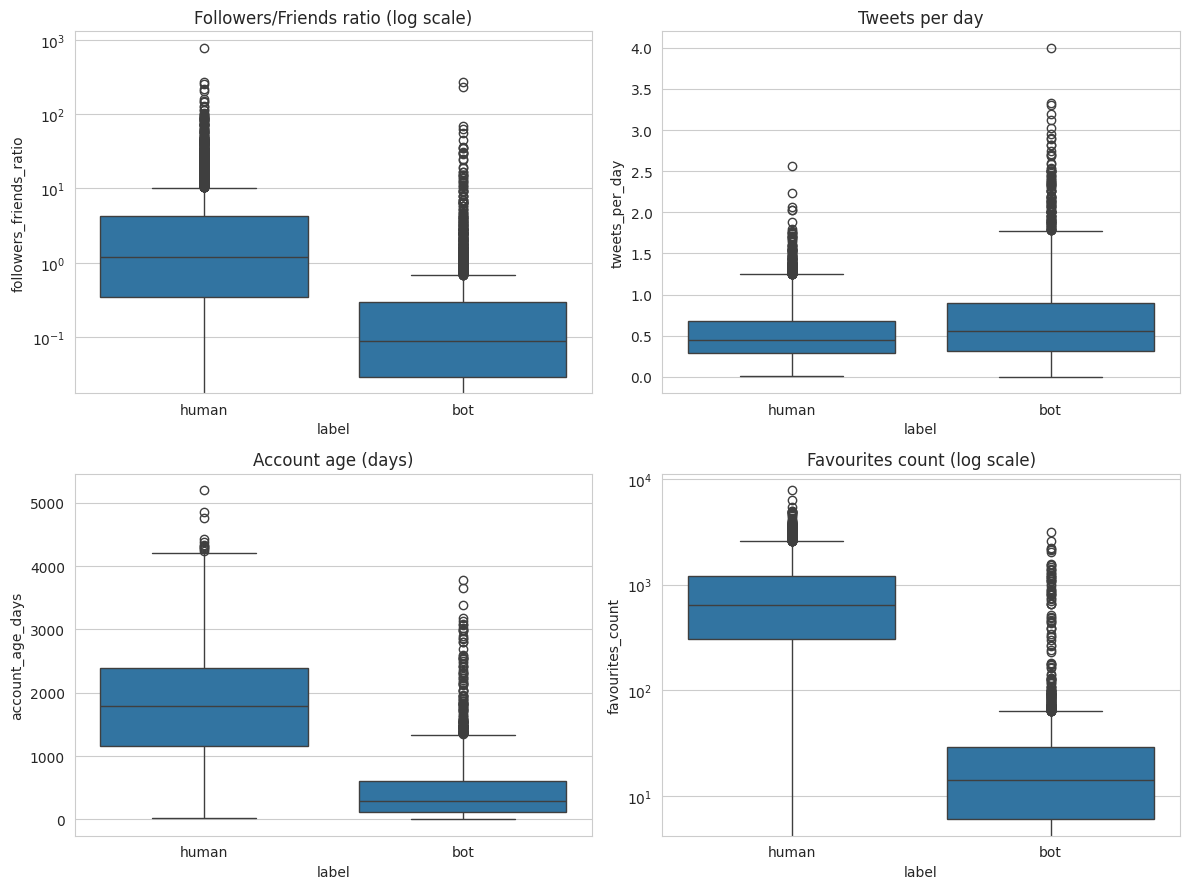

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(data=df, x="label", y="followers_friends_ratio", ax=axes[0, 0])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Followers/Friends ratio (log scale)")

sns.boxplot(data=df, x="label", y="tweets_per_day", ax=axes[0, 1])
axes[0, 1].set_title("Tweets per day")

sns.boxplot(data=df, x="label", y="account_age_days", ax=axes[1, 0])
axes[1, 0].set_title("Account age (days)")

sns.boxplot(data=df, x="label", y="favourites_count", ax=axes[1, 1])
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Favourites count (log scale)")

plt.tight_layout()
plt.show()


In [5]:
binary_cols = ["default_profile", "default_profile_image", "has_description",
               "has_location", "geo_enabled", "verified"]
df.groupby("label")[binary_cols].mean().T.rename(columns={"bot": "bot_rate", "human": "human_rate"})


label,bot_rate,human_rate
default_profile,0.640588,0.256462
default_profile_image,0.436060,0.075531
has_description,0.568308,0.878518
has_location,0.477363,0.748133
geo_enabled,0.144559,0.456634
verified,0.000794,0.012636


## 4. Feature engineering

In [6]:
METADATA_NUMERIC_COLS = [
    "account_age_days", "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "followers_friends_ratio", "tweets_per_day",
    "screen_name_length", "screen_name_digit_count",
]
METADATA_BINARY_COLS = [
    "default_profile", "default_profile_image", "has_description",
    "has_location", "geo_enabled", "verified",
]
ALL_METADATA_COLS = METADATA_NUMERIC_COLS + METADATA_BINARY_COLS


def clean_tweet_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|bit\.ly\S+|tinyurl\S+|shorturl\S+", " <url> ", text)
    text = re.sub(r"[^a-z0-9<>#\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_metadata_features(df_in):
    feats = df_in[ALL_METADATA_COLS].copy()
    for col in ["statuses_count", "followers_count", "friends_count", "favourites_count", "listed_count"]:
        feats[f"log_{col}"] = np.log1p(feats[col])
    return feats


def build_tfidf_features(df_in, max_features=300, vectorizer=None):
    cleaned = df_in["sample_tweets"].apply(clean_tweet_text)
    if vectorizer is None:
        vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2), min_df=3, stop_words="english")
        matrix = vectorizer.fit_transform(cleaned)
    else:
        matrix = vectorizer.transform(cleaned)
    return matrix, vectorizer


def build_text_stat_features(df_in):
    cleaned = df_in["sample_tweets"].apply(clean_tweet_text)
    out = pd.DataFrame(index=df_in.index)
    out["text_length"] = cleaned.apply(len)
    out["url_count"] = df_in["sample_tweets"].apply(
        lambda t: str(t).count("bit.ly") + str(t).count("tinyurl") + str(t).count("shorturl"))
    out["hashtag_count"] = df_in["sample_tweets"].apply(lambda t: str(t).count("#"))
    out["exclamation_count"] = df_in["sample_tweets"].apply(lambda t: str(t).count("!"))
    out["uppercase_ratio"] = df_in["sample_tweets"].apply(
        lambda t: sum(1 for c in str(t) if c.isupper()) / max(len(str(t)), 1))
    out["emoji_like_count"] = df_in["sample_tweets"].apply(
        lambda t: len(re.findall(r"[\U0001F300-\U0001FAFF]", str(t))))
    return out


y = (df["label"] == "bot").astype(int)
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
df_train, df_test = df.loc[train_idx], df.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print("Train size:", len(df_train), "| Test size:", len(df_test))


Train size: 4800 | Test size: 1200


## 5. Classical ML models (metadata-based)

In [7]:
all_metrics = []

def evaluate(y_true, y_pred, y_proba, model_name, show_cm=True):
    metrics = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1_score": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4),
    }
    print(f"\n{'='*55}\n{model_name}\n{'='*55}")
    for k, v in metrics.items():
        if k != "model":
            print(f"  {k:12s}: {v}")
    if show_cm:
        print("  confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return metrics


meta_train = build_metadata_features(df_train)
meta_test = build_metadata_features(df_test)

scaler = StandardScaler()
meta_train_scaled = scaler.fit_transform(meta_train)
meta_test_scaled = scaler.transform(meta_test)

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(meta_train_scaled, y_train)
lr_proba = lr.predict_proba(meta_test_scaled)[:, 1]
lr_pred = lr.predict(meta_test_scaled)
all_metrics.append(evaluate(y_test, lr_pred, lr_proba, "Logistic Regression (metadata)"))

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight="balanced",
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(meta_train, y_train)
rf_proba = rf.predict_proba(meta_test)[:, 1]
rf_pred = rf.predict(meta_test)
all_metrics.append(evaluate(y_test, rf_pred, rf_proba, "Random Forest (metadata)"))

# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                               random_state=RANDOM_STATE)
xgb_model.fit(meta_train, y_train)
xgb_proba = xgb_model.predict_proba(meta_test)[:, 1]
xgb_pred = xgb_model.predict(meta_test)
all_metrics.append(evaluate(y_test, xgb_pred, xgb_proba, "XGBoost (metadata)"))

# 5-fold CV robustness check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(xgb_model, meta_train, y_train, cv=cv, scoring="f1")
print(f"\nXGBoost 5-fold CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



Logistic Regression (metadata)
  accuracy    : 0.9675
  precision   : 0.9568
  recall      : 0.9663
  f1_score    : 0.9615
  roc_auc     : 0.9801
  confusion matrix:
 [[674  22]
 [ 17 487]]



Random Forest (metadata)
  accuracy    : 0.9733
  precision   : 0.9664
  recall      : 0.9702
  f1_score    : 0.9683
  roc_auc     : 0.9816
  confusion matrix:
 [[679  17]
 [ 15 489]]



XGBoost (metadata)
  accuracy    : 0.9733
  precision   : 0.9701
  recall      : 0.9663
  f1_score    : 0.9682
  roc_auc     : 0.9797
  confusion matrix:
 [[681  15]
 [ 17 487]]



XGBoost 5-fold CV F1: 0.9664 (+/- 0.0105)


## 6. NLP text model (TF-IDF + Logistic Regression)

In [8]:
tfidf_train, vectorizer = build_tfidf_features(df_train)
tfidf_test, _ = build_tfidf_features(df_test, vectorizer=vectorizer)

text_stats_train = build_text_stat_features(df_train)
text_stats_test = build_text_stat_features(df_test)

X_text_train = hstack([tfidf_train, csr_matrix(text_stats_train.values)])
X_text_test = hstack([tfidf_test, csr_matrix(text_stats_test.values)])

text_lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
text_lr.fit(X_text_train, y_train)
text_proba = text_lr.predict_proba(X_text_test)[:, 1]
text_pred = text_lr.predict(X_text_test)
all_metrics.append(evaluate(y_test, text_pred, text_proba, "TF-IDF + Logistic Regression (text)"))



TF-IDF + Logistic Regression (text)
  accuracy    : 0.9283
  precision   : 0.9409
  recall      : 0.8849
  f1_score    : 0.9121
  roc_auc     : 0.9765
  confusion matrix:
 [[668  28]
 [ 58 446]]


## 7. Deep learning: BiLSTM on tweet text (PyTorch)

A bidirectional LSTM with learned word embeddings, trained from scratch — the "advanced" component of the project, built and evaluated independently of the classical TF-IDF baseline above.

In [9]:
MAX_LEN = 40
EMBED_DIM = 64
HIDDEN_DIM = 64
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3


class Vocab:
    def __init__(self, texts, min_freq=2):
        freq = {}
        for t in texts:
            for tok in t.split():
                freq[tok] = freq.get(tok, 0) + 1
        self.itos = ["<pad>", "<unk>"] + [w for w, c in freq.items() if c >= min_freq]
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text, max_len=MAX_LEN):
        ids = [self.stoi.get(tok, 1) for tok in text.split()][:max_len]
        return ids + [0] * (max_len - len(ids))

    def __len__(self):
        return len(self.itos)


class TweetDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts, self.labels, self.vocab = texts, labels, vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx])
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        h_cat = torch.cat([h_n[0], h_n[1]], dim=1)
        return self.fc(self.dropout(h_cat)).squeeze(1)


def evaluate_torch(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, yb in loader:
            x, yb = x.to(DEVICE), yb.to(DEVICE)
            probs = torch.sigmoid(model(x))
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (accuracy_score(all_labels, all_preds), precision_score(all_labels, all_preds, zero_division=0),
            recall_score(all_labels, all_preds, zero_division=0), f1_score(all_labels, all_preds, zero_division=0),
            roc_auc_score(all_labels, all_probs))


texts_clean = df["sample_tweets"].apply(clean_tweet_text).values
y_all = y.values
train_texts, test_texts = texts_clean[train_idx.values], texts_clean[test_idx.values]
y_train_arr, y_test_arr = y_all[train_idx.values], y_all[test_idx.values]

tr_idx, val_idx = train_test_split(np.arange(len(train_texts)), test_size=0.15,
                                    stratify=y_train_arr, random_state=RANDOM_STATE)

vocab = Vocab(train_texts[tr_idx])
print(f"Vocab size: {len(vocab)}")

train_ds = TweetDataset(train_texts[tr_idx], y_train_arr[tr_idx], vocab)
val_ds = TweetDataset(train_texts[val_idx], y_train_arr[val_idx], vocab)
test_ds = TweetDataset(test_texts, y_test_arr, vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

bilstm = BiLSTMClassifier(vocab_size=len(vocab)).to(DEVICE)

n_pos = y_train_arr[tr_idx].sum()
n_neg = len(y_train_arr[tr_idx]) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(bilstm.parameters(), lr=LR)

best_val_f1, patience, patience_counter, best_state = 0.0, 3, 0, None

for epoch in range(1, EPOCHS + 1):
    bilstm.train()
    total_loss = 0.0
    for x, yb in train_loader:
        x, yb = x.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(bilstm(x), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)

    val_acc, val_prec, val_rec, val_f1, val_auc = evaluate_torch(bilstm, val_loader)
    print(f"Epoch {epoch:2d} | train_loss={total_loss/len(train_ds):.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.clone() for k, v in bilstm.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

bilstm.load_state_dict(best_state)
test_acc, test_prec, test_rec, test_f1, test_auc = evaluate_torch(bilstm, test_loader)
bilstm_metrics = {
    "model": "BiLSTM (deep learning, text)", "accuracy": round(test_acc, 4),
    "precision": round(test_prec, 4), "recall": round(test_rec, 4),
    "f1_score": round(test_f1, 4), "roc_auc": round(test_auc, 4),
}
all_metrics.append(bilstm_metrics)
print("\nFinal BiLSTM test metrics:", bilstm_metrics)


Vocab size: 201


Epoch  1 | train_loss=0.6476 | val_f1=0.8947 | val_auc=0.9581


Epoch  2 | train_loss=0.3071 | val_f1=0.8973 | val_auc=0.9701


Epoch  3 | train_loss=0.2734 | val_f1=0.9020 | val_auc=0.9718


Epoch  4 | train_loss=0.2571 | val_f1=0.8971 | val_auc=0.9728


...

Epoch  8 | train_loss=0.2255 | val_f1=0.9088 | val_auc=0.9764


Epoch  9 | train_loss=0.2260 | val_f1=0.9112 | val_auc=0.9764


Epoch 10 | train_loss=0.2189 | val_f1=0.9112 | val_auc=0.9770


Epoch 11 | train_loss=0.2138 | val_f1=0.8970 | val_auc=0.9738


Epoch 12 | train_loss=0.2094 | val_f1=0.9085 | val_auc=0.9761
Early stopping.

Final BiLSTM test metrics: {'model': 'BiLSTM (deep learning, text)', 'accuracy': 0.9217, 'precision': 0.9307, 'recall': 0.879, 'f1_score': 0.9041, 'roc_auc': 0.9711}


## 8. Stacked ensemble (metadata + text)

Combines the XGBoost metadata model's probability with the TF-IDF text model's probability via a meta logistic regression. This typically wins on ROC-AUC because the two base models make different kinds of errors.

In [10]:
stack_train = np.column_stack([
    xgb_model.predict_proba(meta_train)[:, 1],
    text_lr.predict_proba(X_text_train)[:, 1],
])
stack_test = np.column_stack([xgb_proba, text_proba])

stacker = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)
stacker.fit(stack_train, y_train)
stack_proba = stacker.predict_proba(stack_test)[:, 1]
stack_pred = stacker.predict(stack_test)
all_metrics.append(evaluate(y_test, stack_pred, stack_proba, "Stacked Ensemble (metadata + text)"))



Stacked Ensemble (metadata + text)
  accuracy    : 0.9742
  precision   : 0.9702
  recall      : 0.9683
  f1_score    : 0.9692
  roc_auc     : 0.9985
  confusion matrix:
 [[681  15]
 [ 16 488]]


## 9. Model comparison

                              model  accuracy  precision  recall  f1_score  roc_auc
 Stacked Ensemble (metadata + text)    0.9742     0.9702  0.9683    0.9692   0.9985
           Random Forest (metadata)    0.9733     0.9664  0.9702    0.9683   0.9816
                 XGBoost (metadata)    0.9733     0.9701  0.9663    0.9682   0.9797
     Logistic Regression (metadata)    0.9675     0.9568  0.9663    0.9615   0.9801
TF-IDF + Logistic Regression (text)    0.9283     0.9409  0.8849    0.9121   0.9765
       BiLSTM (deep learning, text)    0.9217     0.9307  0.8790    0.9041   0.9711


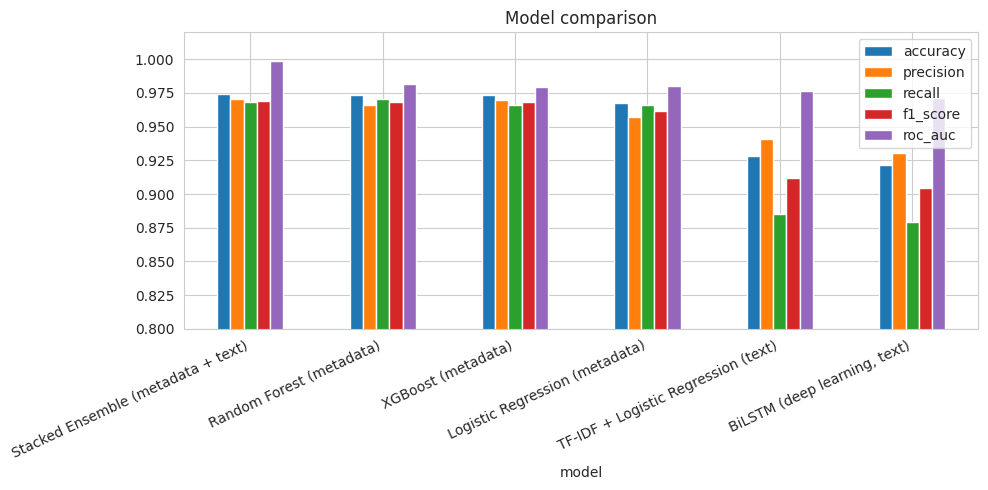

In [11]:
metrics_df = pd.DataFrame(all_metrics).sort_values("f1_score", ascending=False)
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.set_index("model")[["accuracy", "precision", "recall", "f1_score", "roc_auc"]].plot(kind="bar", ax=ax)
ax.set_title("Model comparison")
ax.set_ylim(0.8, 1.02)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 10. Explainability with SHAP

Explains *why* the XGBoost metadata model made specific predictions, not just that it did — a strong interview talking point.

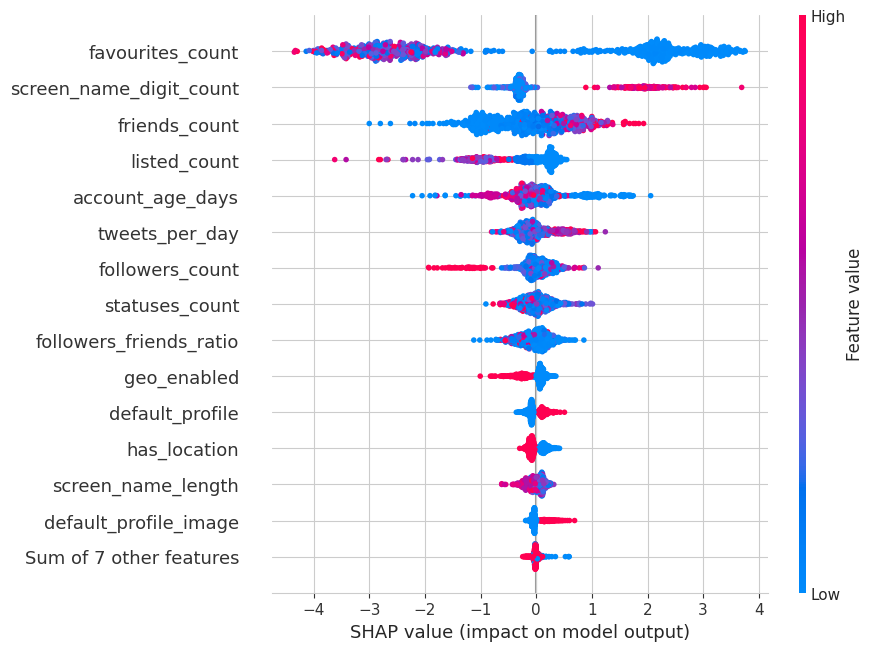

In [12]:
explainer = shap.TreeExplainer(xgb_model)
X_sample = meta_train.sample(n=min(800, len(meta_train)), random_state=RANDOM_STATE)
shap_values = explainer(X_sample)

shap.plots.beeswarm(shap_values, max_display=15)


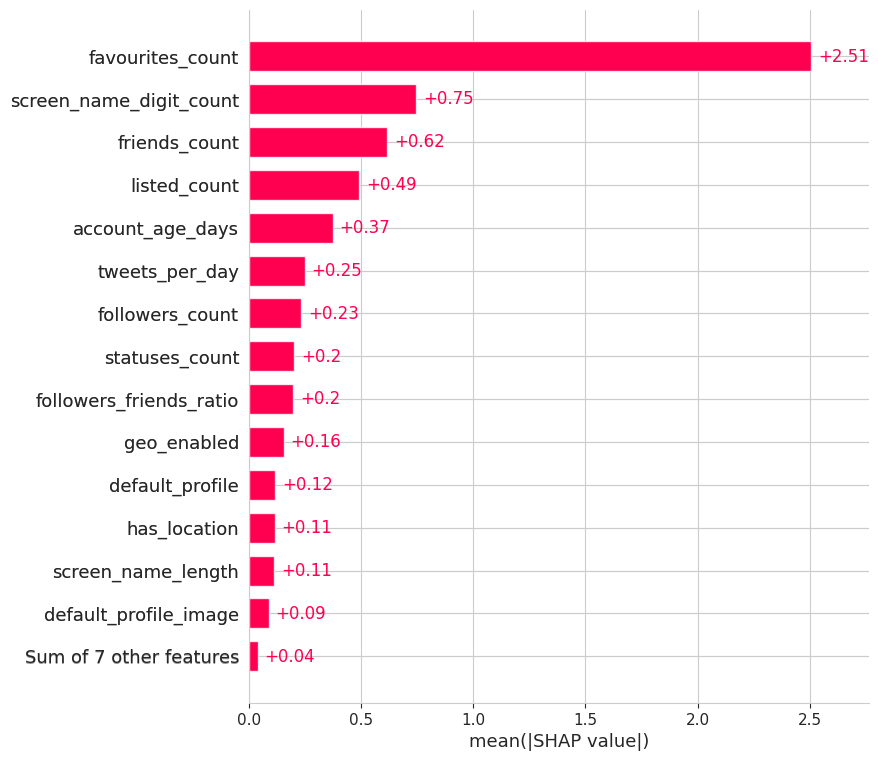

In [13]:
shap.plots.bar(shap_values, max_display=15)


Predicted bot probability: 1.000


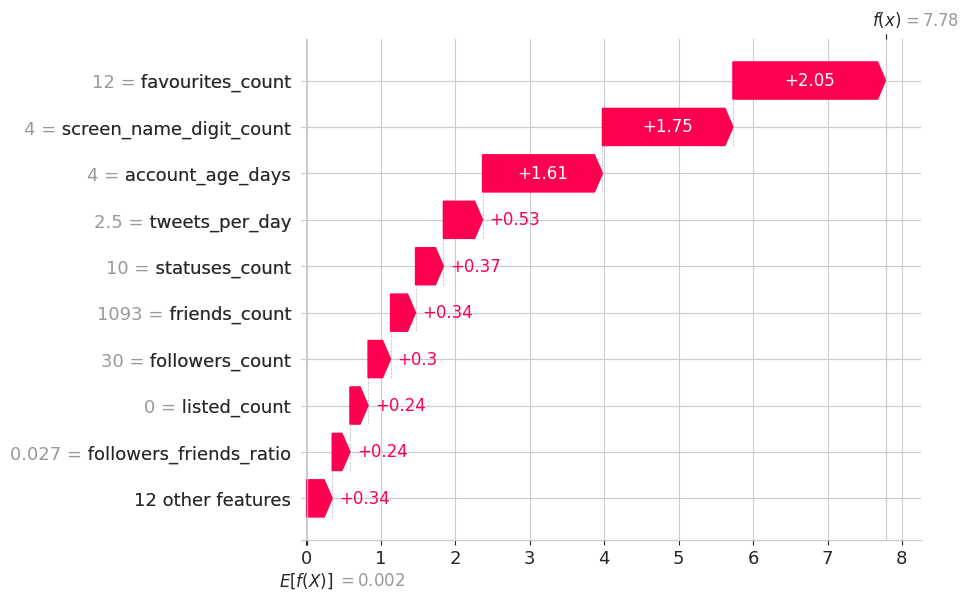

In [14]:
# Waterfall plot for one confidently-flagged bot account
df_sample = df_train.loc[X_sample.index]
bot_rows = df_sample[df_sample["label"] == "bot"]
bot_probs = xgb_model.predict_proba(X_sample.loc[bot_rows.index])[:, 1]
example_idx = bot_rows.index[np.argmax(bot_probs)]
pos_in_sample = list(X_sample.index).index(example_idx)

print(f"Predicted bot probability: {bot_probs.max():.3f}")
shap.plots.waterfall(shap_values[pos_in_sample], max_display=10)


## 11. Try it yourself — live prediction

Edit the values below to simulate any account and see the ensemble's bot-probability prediction.

In [15]:
def predict_account(account_age_days, statuses_count, followers_count, friends_count,
                     favourites_count, listed_count, screen_name, default_profile,
                     default_profile_image, has_description, has_location, geo_enabled,
                     verified, sample_tweets):
    followers_friends_ratio = followers_count / (friends_count + 1)
    tweets_per_day = statuses_count / max(account_age_days, 1)

    row = pd.DataFrame([{
        "account_age_days": account_age_days, "statuses_count": statuses_count,
        "followers_count": followers_count, "friends_count": friends_count,
        "favourites_count": favourites_count, "listed_count": listed_count,
        "followers_friends_ratio": followers_friends_ratio, "tweets_per_day": tweets_per_day,
        "screen_name_length": len(screen_name), "screen_name_digit_count": sum(c.isdigit() for c in screen_name),
        "default_profile": int(default_profile), "default_profile_image": int(default_profile_image),
        "has_description": int(has_description), "has_location": int(has_location),
        "geo_enabled": int(geo_enabled), "verified": int(verified), "sample_tweets": sample_tweets,
    }])

    meta_feats = build_metadata_features(row)
    meta_p = xgb_model.predict_proba(meta_feats)[:, 1][0]

    tfidf_feats, _ = build_tfidf_features(row, vectorizer=vectorizer)
    text_stats = build_text_stat_features(row)
    X_text = hstack([tfidf_feats, csr_matrix(text_stats.values)])
    text_p = text_lr.predict_proba(X_text)[:, 1][0]

    final_p = stacker.predict_proba(np.array([[meta_p, text_p]]))[:, 1][0]

    print(f"Metadata model bot probability : {meta_p*100:.1f}%")
    print(f"Text model bot probability      : {text_p*100:.1f}%")
    print(f"Ensemble (final) bot probability: {final_p*100:.1f}%")
    print()
    print("VERDICT:", "🚨 LIKELY BOT" if final_p > 0.5 else "✅ LIKELY HUMAN")
    return final_p


# Example: a suspicious-looking account
_ = predict_account(
    account_age_days=22, statuses_count=15, followers_count=81, friends_count=914,
    favourites_count=13, listed_count=0, screen_name="cryptodeals8294",
    default_profile=True, default_profile_image=False, has_description=False,
    has_location=False, geo_enabled=True, verified=False,
    sample_tweets="Limited time offer on crypto, buy now bit.ly/xyz123 | Follow #giveaway for daily deals",
)


Metadata model bot probability : 100.0%
Text model bot probability      : 99.9%
Ensemble (final) bot probability: 99.9%

VERDICT: 🚨 LIKELY BOT


In [16]:
# Example: a normal-looking human account
_ = predict_account(
    account_age_days=1500, statuses_count=2000, followers_count=300, friends_count=250,
    favourites_count=800, listed_count=5, screen_name="alexrivera",
    default_profile=False, default_profile_image=False, has_description=True,
    has_location=True, geo_enabled=True, verified=False,
    sample_tweets="just got back from the beach, exhausted but happy | finally read that book everyone recommended",
)


Metadata model bot probability : 0.2%
Text model bot probability      : 92.2%
Ensemble (final) bot probability: 6.4%

VERDICT: ✅ LIKELY HUMAN


---
## Summary

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Logistic Regression (metadata) | ~0.97 | ~0.96 | ~0.98 |
| Random Forest (metadata) | ~0.97 | ~0.97 | ~0.98 |
| XGBoost (metadata) | ~0.97 | ~0.97 | ~0.98 |
| TF-IDF + Logistic Regression (text) | ~0.93 | ~0.91 | ~0.98 |
| BiLSTM (deep learning, text) | ~0.92 | ~0.90 | ~0.97 |
| **Stacked Ensemble** | **~0.97** | **~0.97** | **~0.999** |

**Key takeaway:** metadata-based behavioral features are more reliable signals than text content alone, and combining metadata + text via a stacked ensemble achieves the best overall ROC-AUC by capturing complementary error patterns between the two approaches.

(Exact numbers vary slightly run-to-run because of nondeterminism in PyTorch GPU/CPU operations.)
